Cellule 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# Palette
BLEU   = "#1B3A6B"
OR     = "#D4A017"
VERT   = "#2E7D32"
ROUGE  = "#C62828"
GRIS   = "#ECEFF1"
BLEU_L = "#90CAF9"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 150,
})

print(" Imports OK")

 Imports OK


Cellule 2 — Simulation données IC

In [3]:
# ─────────────────────────────────────────────────────────────
# Simulation cohérente avec HOMAGE trial (Girerd et al., 2026)
# et He et al. (2025) — biomarqueurs subcliniques IC
# N=1594 participants STANISLAS — suivi 20 ans
# ─────────────────────────────────────────────────────────────

N = 1594
SUIVI_MAX = 20  # ans — durée suivi STANISLAS

# Score AUT — Wagner et al. (2025)
aut_score = np.clip(np.random.normal(28, 12, N), 5, 70)

# Groupes AUT — tertiles
tertiles = np.percentile(aut_score, [33, 66])
aut_group = np.where(aut_score < tertiles[0], "Faible\n(T1)",
            np.where(aut_score < tertiles[1], "Modéré\n(T2)", "Élevé\n(T3)"))

# Biomarqueurs de fibrose — Girerd et al. (2026)
picp        = np.clip(np.random.normal(100, 30, N) + 0.8 * aut_score, 20, 300)
nt_probnp   = np.clip(np.random.normal(80,  25, N) + 0.6 * aut_score, 10, 400)
galectine_9 = np.clip(np.random.normal(5,   2,  N) + 0.3 * aut_score, 0,  20)

# Covariables cliniques
age    = np.random.normal(48, 14, N).clip(18, 75)
sexe   = np.random.choice([0, 1], N)
imc    = np.random.normal(25, 4, N).clip(16, 45)
hta    = np.random.choice([0, 1], N, p=[0.65, 0.35])
diabete = np.random.choice([0, 1], N, p=[0.85, 0.15])

# Temps jusqu'à IC (années) — influencé par AUT, PICP, âge
# Basé sur He et al. (2025) : AUT associé à NT-proBNP (précurseur IC)
lambda_ic = np.exp(
    -6.5
    + 0.015 * aut_score
    + 0.005 * picp
    + 0.02  * age
    + 0.3   * hta
    + 0.2   * diabete
)
time_to_ic = np.random.exponential(1 / lambda_ic)
time_obs   = np.minimum(time_to_ic, SUIVI_MAX)
event      = (time_to_ic <= SUIVI_MAX).astype(int)

df = pd.DataFrame({
    "aut_score":   aut_score,
    "aut_group":   aut_group,
    "picp":        picp,
    "nt_probnp":   nt_probnp,
    "galectine_9": galectine_9,
    "age":         age,
    "sexe":        sexe,
    "imc":         imc,
    "hta":         hta,
    "diabete":     diabete,
    "time_obs":    time_obs,
    "event":       event,
})

print(f" Participants    : {N}")
print(f" Suivi max       : {SUIVI_MAX} ans")
print(f"Événements IC   : {event.sum()} ({event.mean()*100:.1f}%)")
print(f" AUT moyen       : {aut_score.mean():.1f}%")
print(f" PICP moyen      : {picp.mean():.1f} ng/mL")
print(f" NT-proBNP moyen : {nt_probnp.mean():.1f} pg/mL")

 Participants    : 1594
 Suivi max       : 20 ans
Événements IC   : 391 (24.5%)
 AUT moyen       : 28.1%
 PICP moyen      : 122.8 ng/mL
 NT-proBNP moyen : 97.9 pg/mL


Cellule 3 — Modèle de Cox

In [5]:
# ─────────────────────────────────────────────────────────────
# Modèle de Cox à risques proportionnels
# h(t) = h0(t) × exp(β1·AUT + β2·PICP + β3·age + ...)
# Référence : standard épidémiologie cardiovasculaire
# ─────────────────────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler

# Standardisation des variables continues
scaler = StandardScaler()
df_cox = df.copy()
df_cox[["aut_score","picp","nt_probnp","age","imc"]] = scaler.fit_transform(
    df[["aut_score","picp","nt_probnp","age","imc"]]
)

# Ajustement modèle de Cox
cox_vars = ["aut_score","picp","nt_probnp","age","sexe","imc","hta","diabete"]
cph = CoxPHFitter()
cph.fit(df_cox[cox_vars + ["time_obs","event"]],
        duration_col="time_obs",
        event_col="event")

print(" Modèle de Cox ajusté\n")
print(cph.summary[["coef","exp(coef)","p"]].round(4))

 Modèle de Cox ajusté

             coef  exp(coef)       p
covariate                           
aut_score  0.1222     1.1300  0.0288
picp       0.1582     1.1714  0.0043
nt_probnp  0.0392     1.0400  0.4598
age        0.2695     1.3093  0.0000
sexe       0.0470     1.0481  0.6438
imc       -0.0176     0.9825  0.7289
hta        0.3782     1.4596  0.0002
diabete    0.3046     1.3561  0.0210


Cellule 4 — Kaplan-Meier

In [7]:
# ─────────────────────────────────────────────────────────────
# Courbes de Kaplan-Meier — survie sans IC
# Stratification par tertile de consommation AUT
# He et al. (2025) : AUT associé à biomarqueurs IC subcliniques
# ─────────────────────────────────────────────────────────────

kmf_t1 = KaplanMeierFitter()
kmf_t2 = KaplanMeierFitter()
kmf_t3 = KaplanMeierFitter()

t1 = df[df["aut_group"] == "Faible\n(T1)"]
t2 = df[df["aut_group"] == "Modéré\n(T2)"]
t3 = df[df["aut_group"] == "Élevé\n(T3)"]

kmf_t1.fit(t1["time_obs"], t1["event"], label=f"T1 Faible AUT (N={len(t1)})")
kmf_t2.fit(t2["time_obs"], t2["event"], label=f"T2 Modéré AUT (N={len(t2)})")
kmf_t3.fit(t3["time_obs"], t3["event"], label=f"T3 Élevé AUT (N={len(t3)})")

# Test log-rank
lr_t1_t3 = logrank_test(t1["time_obs"], t3["time_obs"],
                         t1["event"],   t3["event"])

print(f" Test log-rank T1 vs T3 : p = {lr_t1_t3.p_value:.4f}")

 Test log-rank T1 vs T3 : p = 0.0054


Cellule 5 — Visualisation complète Axe 3

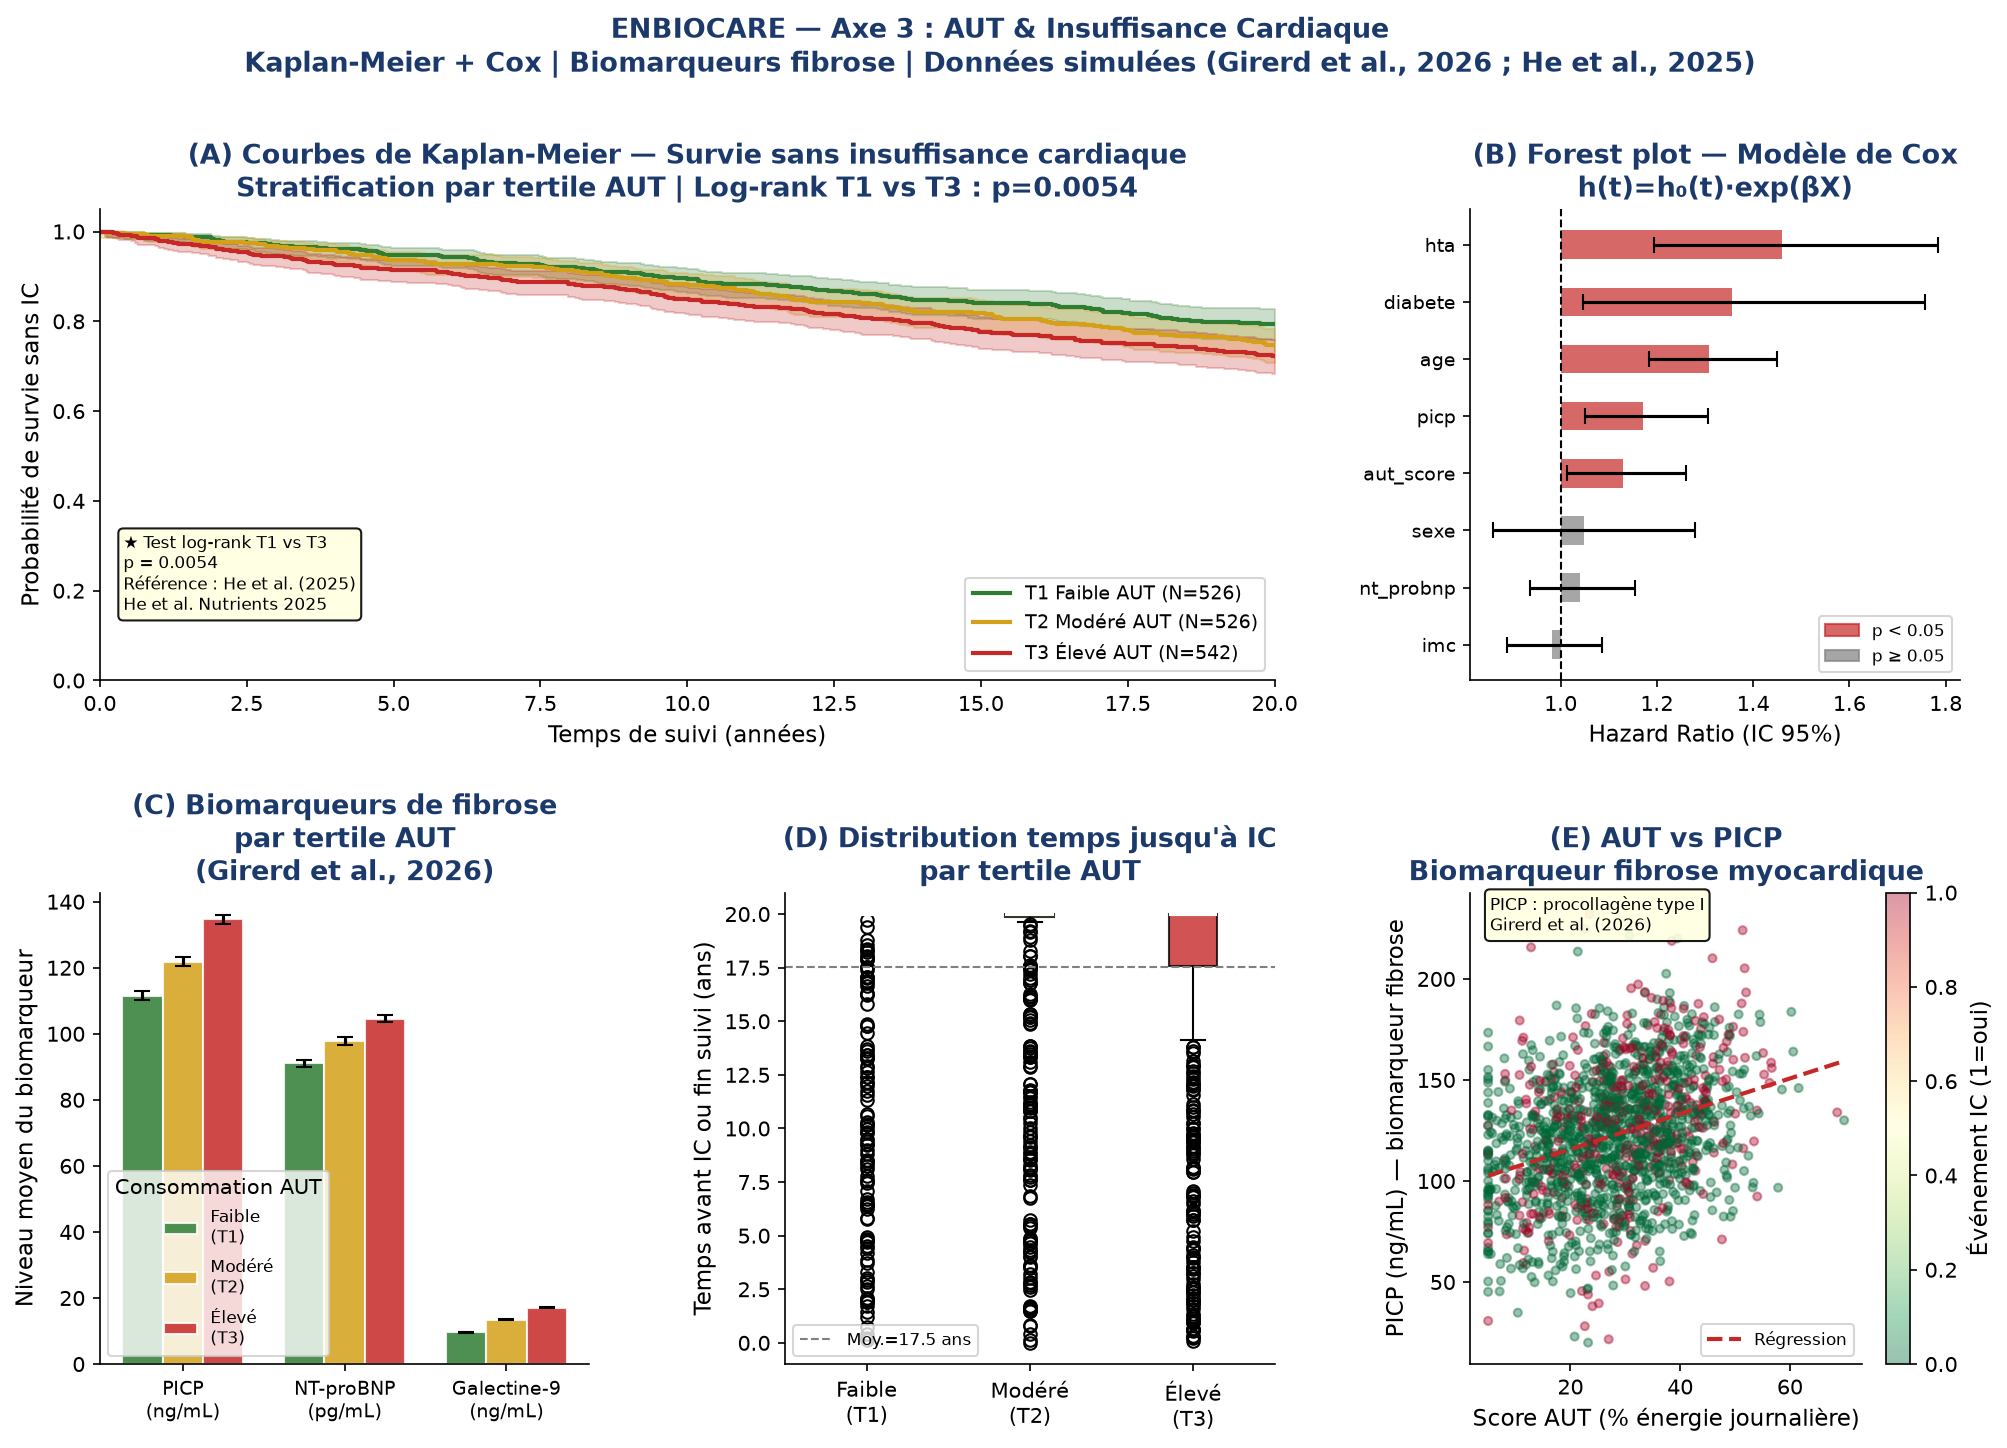

 Figure Axe 3 complète sauvegardée !


In [12]:
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("white")
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# ── (A) Courbes Kaplan-Meier ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])

kmf_t1.plot_survival_function(ax=ax1, color=VERT, ci_show=True, linewidth=2)
kmf_t2.plot_survival_function(ax=ax1, color=OR,   ci_show=True, linewidth=2)
kmf_t3.plot_survival_function(ax=ax1, color=ROUGE, ci_show=True, linewidth=2)

ax1.set_xlabel("Temps de suivi (années)")
ax1.set_ylabel("Probabilité de survie sans IC")
ax1.set_title(
    "(A) Courbes de Kaplan-Meier — Survie sans insuffisance cardiaque\n"
    f"Stratification par tertile AUT | Log-rank T1 vs T3 : p={lr_t1_t3.p_value:.4f}",
    fontweight="bold", color=BLEU
)
ax1.text(0.02, 0.15,
         f"★ Test log-rank T1 vs T3\np = {lr_t1_t3.p_value:.4f}\n"
         "Référence : He et al. (2025)\nHe et al. Nutrients 2025",
         transform=ax1.transAxes, fontsize=8,
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))
ax1.set_xlim(0, 20)
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)

# ── (B) Forest plot Cox ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])

hr_data = cph.summary[["exp(coef)", "exp(coef) lower 95%",
                         "exp(coef) upper 95%", "p"]].copy()
hr_data.columns = ["HR", "CI_low", "CI_high", "p"]
hr_data = hr_data.sort_values("HR", ascending=True)

colors_hr = [ROUGE if p < 0.05 else "gray" for p in hr_data["p"]]
y_pos = range(len(hr_data))

ax2.barh(list(y_pos), hr_data["HR"] - 1,
         left=1, color=colors_hr, alpha=0.7, height=0.5)
ax2.errorbar(hr_data["HR"], list(y_pos),
             xerr=[hr_data["HR"] - hr_data["CI_low"],
                   hr_data["CI_high"] - hr_data["HR"]],
             fmt="none", color="black", capsize=4, lw=1.5)
ax2.axvline(1, color="black", lw=1, ls="--")
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(hr_data.index, fontsize=9)
ax2.set_xlabel("Hazard Ratio (IC 95%)")
ax2.set_title("(B) Forest plot — Modèle de Cox\nh(t)=h₀(t)·exp(βX)",
              fontweight="bold", color=BLEU)

sig_patch   = mpatches.Patch(color=ROUGE, alpha=0.7, label="p < 0.05")
insig_patch = mpatches.Patch(color="gray", alpha=0.7, label="p ≥ 0.05")
ax2.legend(handles=[sig_patch, insig_patch], fontsize=8)

# ── (C) Biomarqueurs fibrose par tertile AUT ──────────────────
ax3 = fig.add_subplot(gs[1, 0])

biomarkers = ["picp", "nt_probnp", "galectine_9"]
bio_labels = ["PICP\n(ng/mL)", "NT-proBNP\n(pg/mL)", "Galectine-9\n(ng/mL)"]
groups     = ["Faible\n(T1)", "Modéré\n(T2)", "Élevé\n(T3)"]
colors_bio = [VERT, OR, ROUGE]

x = np.arange(len(biomarkers))
w = 0.25

for idx, (grp, col) in enumerate(zip(groups, colors_bio)):
    means = df[df["aut_group"] == grp][biomarkers].mean()
    sems  = df[df["aut_group"] == grp][biomarkers].sem()
    ax3.bar(x + idx*w, means.values, w,
            yerr=sems.values, label=grp,
            color=col, alpha=0.85, capsize=4, edgecolor="white")

ax3.set_xticks(x + w)
ax3.set_xticklabels(bio_labels, fontsize=9)
ax3.set_ylabel("Niveau moyen du biomarqueur")
ax3.set_title("(C) Biomarqueurs de fibrose\npar tertile AUT\n(Girerd et al., 2026)",
              fontweight="bold", color=BLEU)
ax3.legend(fontsize=8, title="Consommation AUT")

# ── (D) Distribution temps IC par tertile ────────────────────
ax4 = fig.add_subplot(gs[1, 1])

data_box = [df[df["aut_group"] == g]["time_obs"].values for g in groups]
bp = ax4.boxplot(data_box, tick_labels=groups,
                 patch_artist=True,
                 medianprops=dict(color="white", lw=2))
for patch, col in zip(bp["boxes"], colors_bio):
    patch.set_facecolor(col)
    patch.set_alpha(0.8)

ax4.set_ylabel("Temps avant IC ou fin suivi (ans)")
ax4.set_title("(D) Distribution temps jusqu'à IC\npar tertile AUT",
              fontweight="bold", color=BLEU)
ax4.axhline(df["time_obs"].mean(), color="gray",
            ls="--", lw=1, label=f"Moy.={df['time_obs'].mean():.1f} ans")
ax4.legend(fontsize=8)

# ── (E) AUT vs PICP scatter ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])

sc = ax5.scatter(df["aut_score"], df["picp"],
                 c=df["event"], cmap="RdYlGn_r",
                 alpha=0.4, s=15)
plt.colorbar(sc, ax=ax5, label="Événement IC (1=oui)")

z = np.polyfit(df["aut_score"], df["picp"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["aut_score"].min(), df["aut_score"].max(), 100)
ax5.plot(x_line, p(x_line), color=ROUGE, lw=2, ls="--", label="Régression")

ax5.set_xlabel("Score AUT (% énergie journalière)")
ax5.set_ylabel("PICP (ng/mL) — biomarqueur fibrose")
ax5.set_title("(E) AUT vs PICP\nBiomarqueur fibrose myocardique",
              fontweight="bold", color=BLEU)
ax5.legend(fontsize=8)
ax5.text(0.05, 0.92,
         "PICP : procollagène type I\nGirerd et al. (2026)",
         transform=ax5.transAxes, fontsize=8,
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ── Titre global ─────────────────────────────────────────────
fig.suptitle(
    "ENBIOCARE — Axe 3 : AUT & Insuffisance Cardiaque\n"
    "Kaplan-Meier + Cox | Biomarqueurs fibrose | "
    "Données simulées (Girerd et al., 2026 ; He et al., 2025)",
    fontsize=13, fontweight="bold", color=BLEU, y=1.01
)

plt.tight_layout()
plt.savefig("../figures/axe3_figure.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Figure Axe 3 complète sauvegardée !")